# Inteligência Artificial — LAB LEGO: redes neurais artificiais
**PUC-SP · Ciência da Computação · Machine Learning com Scikit-learn**

Atividade completa: baixar e carregar dados, visualizar valores faltantes, limpar a base, treinar uma ANN e criar `price` para todos os conjuntos. Preços em **dólares americanos (USD), no lançamento**, conforme o dicionário da base; não são preços atuais, de revenda ou convertidos para reais.

**Integrantes:** Nicolas Mariano da Silva e Pedro Henrique Isamu Yoshissaro

Execute as células em ordem (Jupyter, VS Code ou Google Colab). Ao final, publique este `.ipynb` no seu GitHub e envie o link no Teams. A publicação depende da sua conta e do repositório escolhido.

Fonte: [Maven Analytics — LEGO Sets](https://mavenanalytics.io/data-playground/lego-sets), com lançamentos entre 1970 e 2022. O arquivo original fica preservado em `US_retailPrice`; a nova coluna `price` contém os preços observados e as estimativas.

## 1. Dependências e configuração
A instalação só ocorre se alguma biblioteca estiver ausente. `MLPRegressor` implementa uma rede neural com múltiplas camadas para **regressão**, pois o preço é uma variável numérica contínua.

In [1]:
import importlib.util
import subprocess
import sys
pacotes = {'numpy': 'numpy', 'pandas': 'pandas', 'matplotlib': 'matplotlib',
           'seaborn': 'seaborn', 'missingno': 'missingno', 'sklearn': 'scikit-learn',
           'joblib': 'joblib', 'threadpoolctl': 'threadpoolctl'}
ausentes = [pip_name for module, pip_name in pacotes.items()
            if importlib.util.find_spec(module) is None]
if ausentes:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *ausentes])

from pathlib import Path
from io import BytesIO
from urllib.request import urlopen
from zipfile import ZipFile
import json
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import sklearn
import joblib
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neural_network import MLPRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from threadpoolctl import threadpool_limits

SEED = 42
PASTA = Path('dados_lego')
SAIDA = Path('resultados_lego')
PASTA.mkdir(exist_ok=True)
SAIDA.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 25)
print('Python:', platform.python_version(), '| scikit-learn:', sklearn.__version__)

Python: 3.12.14 | scikit-learn: 1.8.0


## 2. Download e leitura
O download é feito em Python, compatível também com Windows. Apenas os dois CSVs esperados são copiados do ZIP. Arquivos já disponíveis são reutilizados.

In [2]:
URL = 'https://maven-datasets.s3.amazonaws.com/LEGO+Sets/LEGO+Sets.zip'
for nome in ['lego_sets.csv', 'lego_sets_data_dictionary.csv']:
    # Reutiliza os CSVs do pacote completo, se disponíveis junto ao notebook.
    origem = Path(nome)
    destino = PASTA / nome
    if origem.exists() and not destino.exists():
        destino.write_bytes(origem.read_bytes())
if not all((PASTA / nome).exists() for nome in ['lego_sets.csv', 'lego_sets_data_dictionary.csv']):
    with urlopen(URL, timeout=60) as resposta:
        conteudo = resposta.read()
    with ZipFile(BytesIO(conteudo)) as arquivo:
        for nome in ['lego_sets.csv', 'lego_sets_data_dictionary.csv']:
            (PASTA / nome).write_bytes(arquivo.read(nome))
lego_original = pd.read_csv(PASTA / 'lego_sets.csv')
dicionario = pd.read_csv(PASTA / 'lego_sets_data_dictionary.csv')
print(f'{lego_original.shape[0]:,} linhas e {lego_original.shape[1]} colunas.')
display(lego_original.head())
display(dicionario)

18,457 linhas e 14 colunas.


,set_id,name,year,theme,subtheme,themeGroup,category,pieces,minifigs,agerange_min,US_retailPrice,bricksetURL,thumbnailURL,imageURL
0,1-8,Small house set,1970,Minitalia,NaN,Vintage,Normal,67.0,NaN,NaN,NaN,https://brickset.com/sets/1-8,https://images.brickset.com/sets/small/1-8.jpg,https://images.brickset.com/sets/images/1-8.jpg
1,2-8,Medium house set,1970,Minitalia,NaN,Vintage,Normal,109.0,NaN,NaN,NaN,https://brickset.com/sets/2-8,https://images.brickset.com/sets/small/2-8.jpg,https://images.brickset.com/sets/images/2-8.jpg
2,3-6,Medium house set,1970,Minitalia,NaN,Vintage,Normal,158.0,NaN,NaN,NaN,https://brickset.com/sets/3-6,https://images.brickset.com/sets/small/3-6.jpg,https://images.brickset.com/sets/images/3-6.jpg
3,4-4,Large house set,1970,Minitalia,NaN,Vintage,Normal,233.0,NaN,NaN,NaN,https://brickset.com/sets/4-4,https://images.brickset.com/sets/small/4-4.jpg,https://images.brickset.com/sets/images/4-4.jpg
4,4-6,Mini House and Vehicles,1970,Samsonite,Model Maker,Vintage,Normal,NaN,NaN,NaN,NaN,https://brickset.com/sets/4-6,NaN,NaN


,Field,Description
0,set_id,Official LEGO item number
1,name,Name of the LEGO set
2,year,Release year
3,theme,LEGO theme the set belongs to
4,subtheme,Subtheme within the theme
5,themeGroup,Overall group the theme belongs to
6,category,Type of set
7,pieces,Number of pieces in the set
8,minifigs,Number of mini figures included in the set
9,agerange_min,Minimum age recommended


## 3. Exploração dos dados e valores ausentes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18457 entries, 0 to 18456
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   set_id          18457 non-null  object 
 1   name            18457 non-null  object 
 2   year            18457 non-null  int64  
 3   theme           18457 non-null  object 
 4   subtheme        14901 non-null  object 
 5   themeGroup      18455 non-null  object 
 6   category        18457 non-null  object 
 7   pieces          14533 non-null  float64
 8   minifigs        8399 non-null   float64
 9   agerange_min    6787 non-null   float64
 10  US_retailPrice  6982 non-null   float64
 11  bricksetURL     18457 non-null  object 
 12  thumbnailURL    17451 non-null  object 
 13  imageURL        17451 non-null  object 
dtypes: float64(4), int64(1), object(9)
memory usage: 2.0+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
set_id,18457,18457,1-8,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,18457,15374,Bonus/Value Pack,165,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,18457.0,NaN,NaN,NaN,2007.960611,11.948666,1970.0,2001.0,2011.0,2017.0,2022.0
theme,18457,154,Gear,2832,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subtheme,14901,895,Magazine Gift,453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
themeGroup,18455,16,Miscellaneous,5891,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,18457,7,Normal,12757,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pieces,14533.0,NaN,NaN,NaN,226.473749,469.988785,0.0,23.0,70.0,242.0,11695.0
minifigs,8399.0,NaN,NaN,NaN,2.66365,2.897857,1.0,1.0,2.0,3.0,80.0
agerange_min,6787.0,NaN,NaN,NaN,6.637542,2.780091,1.0,5.0,6.0,8.0,18.0


,quantidade,percentual
agerange_min,11670,63.23
US_retailPrice,11475,62.17
minifigs,10058,54.49
pieces,3924,21.26
subtheme,3556,19.27
imageURL,1006,5.45
thumbnailURL,1006,5.45
themeGroup,2,0.01
set_id,0,0.00
name,0,0.00


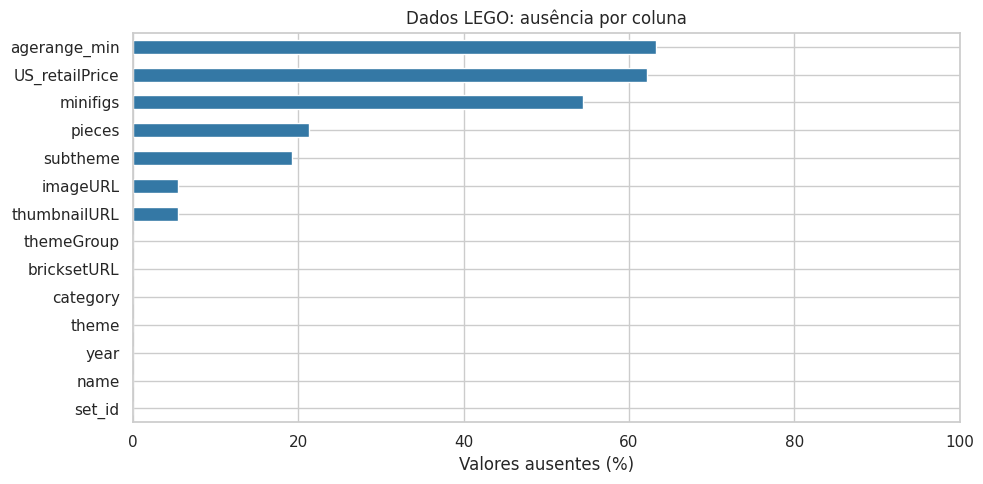

In [3]:
lego_original.info()
display(lego_original.describe(include='all').T)
faltantes = pd.DataFrame({'quantidade': lego_original.isna().sum(),
                          'percentual': lego_original.isna().mean() * 100})
display(faltantes.sort_values('percentual', ascending=False).round(2))
fig, ax = plt.subplots(figsize=(10, 5))
faltantes['percentual'].sort_values().plot.barh(ax=ax, color='#3478a5')
ax.set(xlabel='Valores ausentes (%)', title='Dados LEGO: ausência por coluna', xlim=(0, 100))
plt.tight_layout()
plt.show()

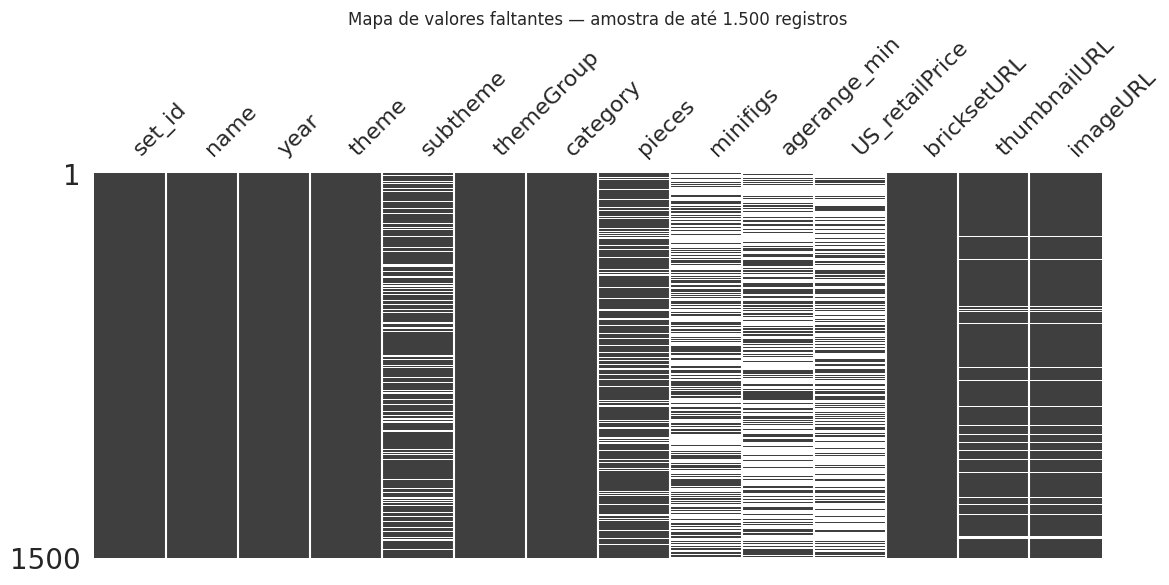

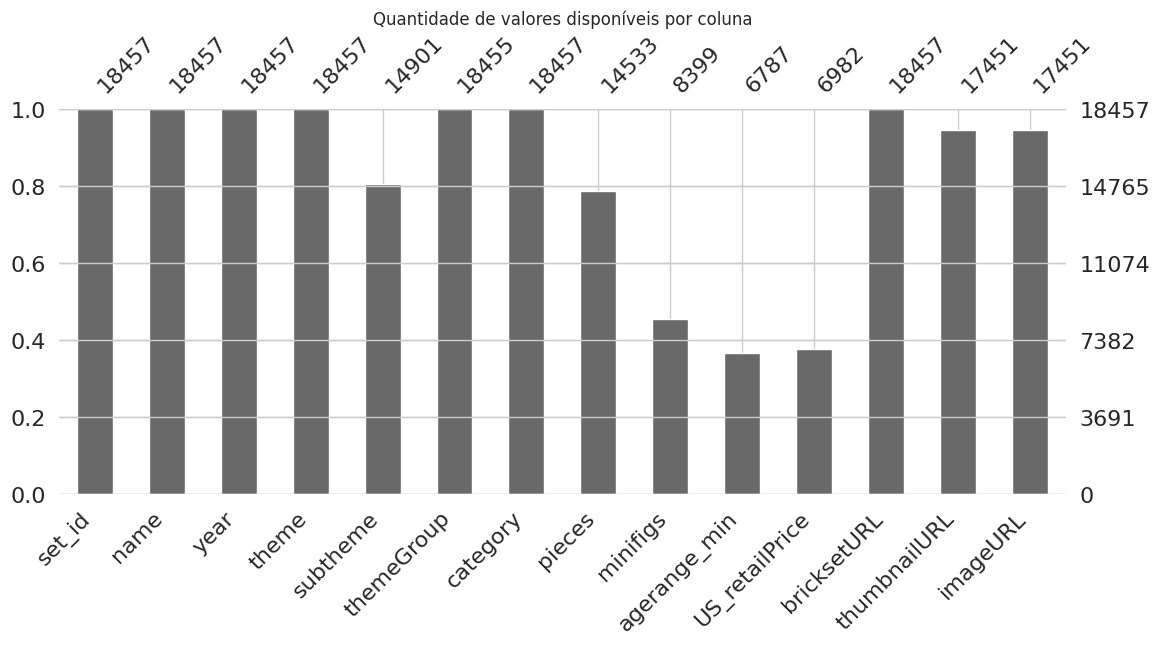

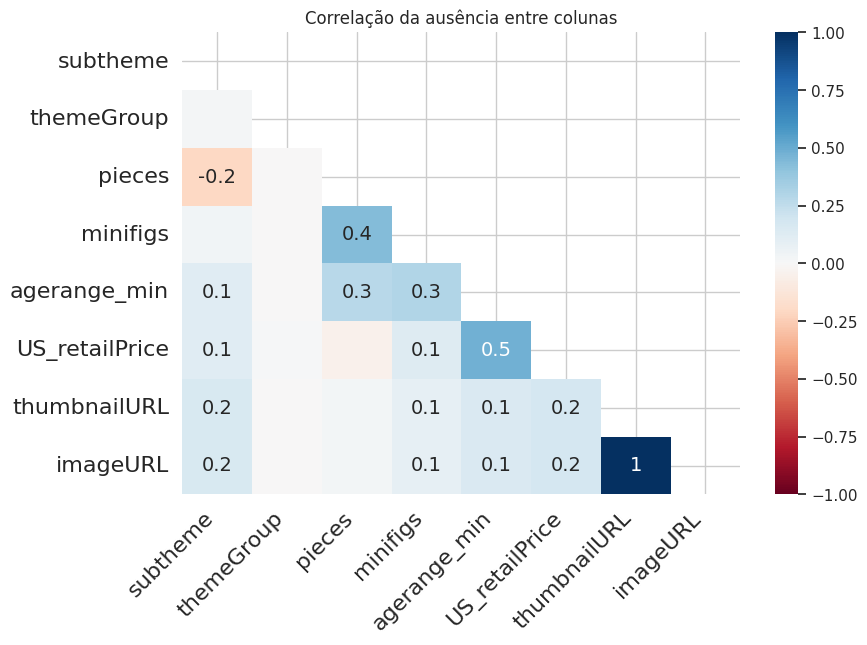

In [4]:
msno.matrix(lego_original.sample(min(1500, len(lego_original)), random_state=SEED), figsize=(13, 5), sparkline=False)
plt.title('Mapa de valores faltantes — amostra de até 1.500 registros')
plt.show()
msno.bar(lego_original, figsize=(13, 5))
plt.title('Quantidade de valores disponíveis por coluna')
plt.show()
msno.heatmap(lego_original, figsize=(9, 6))
plt.title('Correlação da ausência entre colunas')
plt.show()

O mapa mostra onde faltam dados; as barras mostram quantos valores estão disponíveis. O mapa de correlação indica se duas colunas costumam estar ausentes juntas; **não é a correlação entre seus valores**. Não preencheremos o preço com a média antes do treino, pois isso criaria rótulos artificiais.

## 4. Limpeza e organização
- Remover duplicatas exatas e verificar a unicidade de `set_id`.
- Aparar espaços e representar textos vazios como ausentes.
- Converter medidas para valores numéricos; tratar valores negativos ou preços não positivos como inválidos.
- Manter conjuntos sem preço e sem atributos completos: eles também precisam receber estimativas.
- Imputar atributos apenas dentro do pipeline, ajustado no treino, para evitar vazamento de dados. Ausência de minifiguras **não é automaticamente zero**.

Não excluímos preços altos só por serem altos: conjuntos grandes podem ter preços elevados legítimos.

In [5]:
lego_df = lego_original.copy()
antes = len(lego_df)
lego_df = lego_df.drop_duplicates().reset_index(drop=True)
print('Duplicatas exatas removidas:', antes - len(lego_df))
for col in lego_df.select_dtypes(include='object').columns:
    lego_df[col] = lego_df[col].str.strip().replace('', np.nan)
for col in ['year', 'pieces', 'minifigs', 'agerange_min', 'US_retailPrice']:
    lego_df[col] = pd.to_numeric(lego_df[col], errors='coerce')
    invalidos = lego_df[col].lt(0)
    if col == 'US_retailPrice':
        invalidos |= lego_df[col].eq(0)
    print(f'{col}: {invalidos.sum()} valores inválidos tratados como ausentes')
    lego_df.loc[invalidos, col] = np.nan
assert lego_df['set_id'].notna().all(), 'Existem identificadores ausentes.'
assert not lego_df['set_id'].duplicated().any(), 'Investigue IDs repetidos antes de treinar.'
print('Preços conhecidos:', lego_df['US_retailPrice'].notna().sum())
print('Preços a estimar:', lego_df['US_retailPrice'].isna().sum())
display(lego_df.head())

Duplicatas exatas removidas: 0
year: 0 valores inválidos tratados como ausentes
pieces: 0 valores inválidos tratados como ausentes
minifigs: 0 valores inválidos tratados como ausentes
agerange_min: 0 valores inválidos tratados como ausentes
US_retailPrice: 0 valores inválidos tratados como ausentes
Preços conhecidos: 6982
Preços a estimar: 11475


,set_id,name,year,theme,subtheme,themeGroup,category,pieces,minifigs,agerange_min,US_retailPrice,bricksetURL,thumbnailURL,imageURL
0,1-8,Small house set,1970.0,Minitalia,NaN,Vintage,Normal,67.0,NaN,NaN,NaN,https://brickset.com/sets/1-8,https://images.brickset.com/sets/small/1-8.jpg,https://images.brickset.com/sets/images/1-8.jpg
1,2-8,Medium house set,1970.0,Minitalia,NaN,Vintage,Normal,109.0,NaN,NaN,NaN,https://brickset.com/sets/2-8,https://images.brickset.com/sets/small/2-8.jpg,https://images.brickset.com/sets/images/2-8.jpg
2,3-6,Medium house set,1970.0,Minitalia,NaN,Vintage,Normal,158.0,NaN,NaN,NaN,https://brickset.com/sets/3-6,https://images.brickset.com/sets/small/3-6.jpg,https://images.brickset.com/sets/images/3-6.jpg
3,4-4,Large house set,1970.0,Minitalia,NaN,Vintage,Normal,233.0,NaN,NaN,NaN,https://brickset.com/sets/4-4,https://images.brickset.com/sets/small/4-4.jpg,https://images.brickset.com/sets/images/4-4.jpg
4,4-6,Mini House and Vehicles,1970.0,Samsonite,Model Maker,Vintage,Normal,NaN,NaN,NaN,NaN,https://brickset.com/sets/4-6,NaN,NaN


## 5. Análises e visualizações
As análises de preço abaixo usam **somente os valores observados**. Misturar preços estimados nesta etapa daria uma impressão artificial sobre a base.

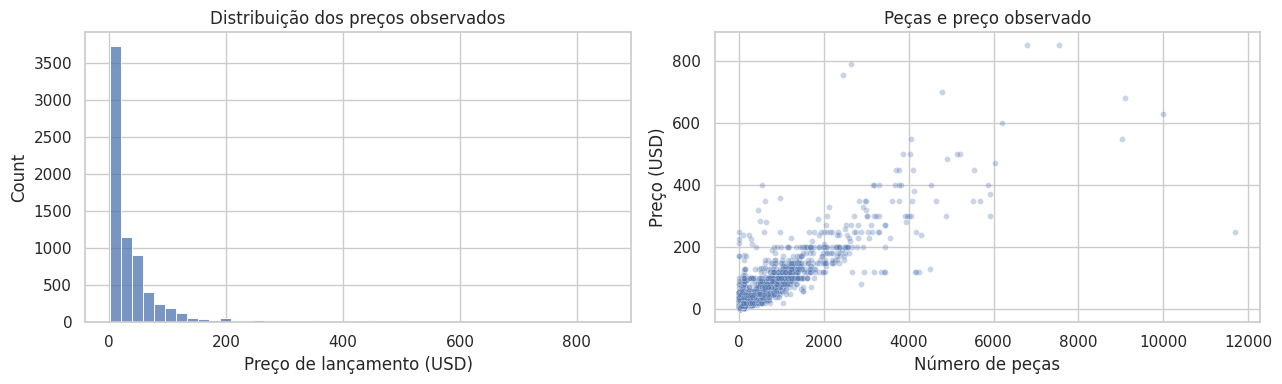

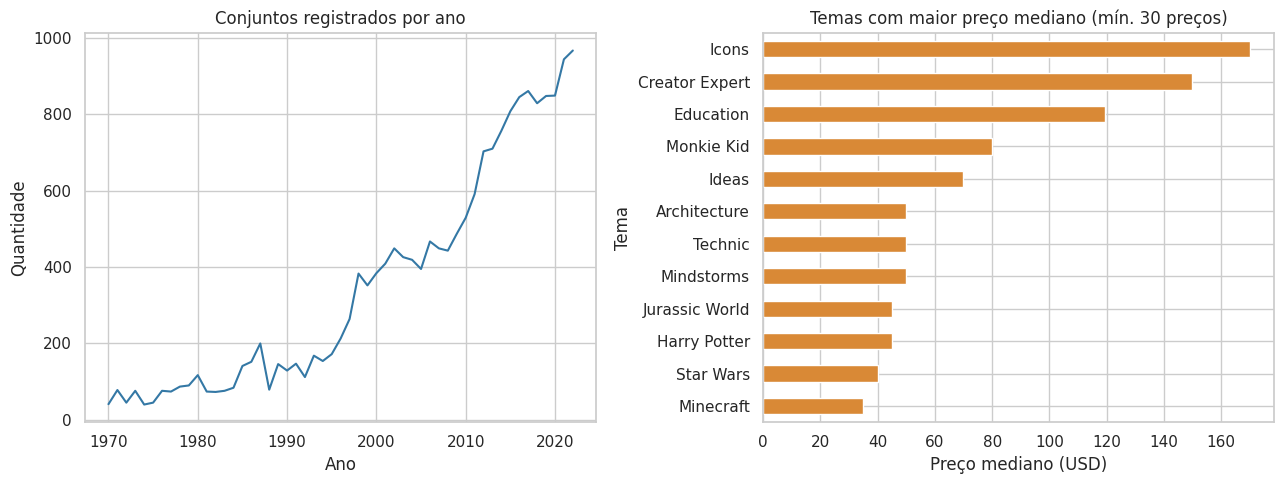

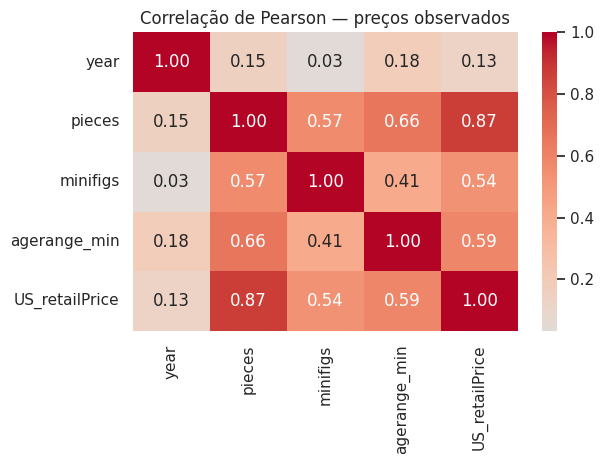

Correlação não implica causalidade; as ausências podem distorcer essas associações.


In [6]:
conhecidos = lego_df.loc[lego_df['US_retailPrice'].notna()].copy()
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=conhecidos, x='US_retailPrice', bins=45, ax=axs[0])
axs[0].set(title='Distribuição dos preços observados', xlabel='Preço de lançamento (USD)')
sns.scatterplot(data=conhecidos, x='pieces', y='US_retailPrice', alpha=0.3, s=18, ax=axs[1])
axs[1].set(title='Peças e preço observado', xlabel='Número de peças', ylabel='Preço (USD)')
plt.tight_layout()
plt.show()
fig, axs = plt.subplots(1, 2, figsize=(13, 5))
lego_df.groupby('year').size().plot(ax=axs[0], color='#3478a5')
axs[0].set(title='Conjuntos registrados por ano', xlabel='Ano', ylabel='Quantidade')
top = conhecidos.groupby('theme')['US_retailPrice'].agg(['count', 'median'])
top = top.loc[top['count'] >= 30].nlargest(12, 'median').sort_values('median')
top['median'].plot.barh(ax=axs[1], color='#d98936')
axs[1].set(title='Temas com maior preço mediano (mín. 30 preços)', xlabel='Preço mediano (USD)', ylabel='Tema')
plt.tight_layout()
plt.show()
corr = conhecidos[['year', 'pieces', 'minifigs', 'agerange_min', 'US_retailPrice']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação de Pearson — preços observados')
plt.tight_layout()
plt.show()
print('Correlação não implica causalidade; as ausências podem distorcer essas associações.')

## 6. Quais colunas são importantes para prever o preço?

| Coluna | Motivo para usar |
|---|---|
| `pieces` | Quantidade de peças: representa tamanho e complexidade. |
| `minifigs` | Minifiguras podem acrescentar valor ao conjunto. |
| `agerange_min` | Idade recomendada pode indicar complexidade. |
| `year` | O preço de lançamento pode variar entre épocas. |
| `theme` | Temas e licenças podem ter faixas de preço diferentes. |
| `themeGroup` | Agrupa temas e ajuda quando há poucos exemplos de um tema. |
| `category` | Distingue conjuntos, acessórios e outros tipos de produto. |

A utilidade real será avaliada por permutação na validação. `set_id` e URLs são identificadores, sem medida direta de custo. `name` exigiria tratamento de texto; `subtheme` tem alta cardinalidade e fica fora desta versão para reduzir complexidade. `US_retailPrice` é o alvo e **não entra como atributo**.

In [7]:
numericas = ['year', 'pieces', 'minifigs', 'agerange_min']
categoricas = ['theme', 'themeGroup', 'category']
atributos = numericas + categoricas
X = conhecidos[atributos]
y = conhecidos['US_retailPrice']
# 60% treino, 20% validação externa e 20% teste.
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_dev, y_dev, test_size=0.25, random_state=SEED)
print('Treino:', len(X_train), '| Validação:', len(X_val), '| Teste:', len(X_test))

# Comparação entre registros com e sem preço: evidencia diferenças de cobertura.
perfil = lego_df.assign(grupo=np.where(lego_df['US_retailPrice'].notna(), 'Com preço', 'Sem preço'))
display(perfil.groupby('grupo')[numericas].median().round(2))
display(pd.crosstab(perfil['category'], perfil['grupo'], normalize='columns').round(3))

Treino: 4188 | Validação: 1397 | Teste: 1397


,year,pieces,minifigs,agerange_min
grupo,,,,
Com preço,2015.0,190.0,3.0,7.0
Sem preço,2004.0,41.0,1.0,5.0


grupo,Com preço,Sem preço
category,,
Book,0.003,0.053
Collection,0.005,0.048
Extended,0.017,0.033
Gear,0.232,0.105
Normal,0.740,0.661
Other,0.002,0.094
Random,0.001,0.005


## 7. Pipeline e treinamento da ANN
As medidas numéricas recebem a mediana do treino e padronização. Indicadores de ausência ajudam a distinguir dados imputados. As categorias recebem um marcador de ausência e codificação one-hot.

Comparamos duas arquiteturas e duas transformações do alvo na validação. O alvo padronizado favorece a escala em USD; `log1p` reduz a influência dos preços muito altos. Escolhemos o menor MAE na validação. O teste permanece reservado até a escolha final.

A ANN usa ativação ReLU, otimizador Adam, regularização L2 e parada antecipada com uma fração interna do treino. A validação interna do MLP controla a parada; a validação externa escolhe a configuração. As métricas finais são medidas em dados não utilizados para ajustar o pipeline.

In [8]:
def criar_modelo(camadas=(64, 32), alvo='padronizado'):
    pre = ColumnTransformer([
        ('num', Pipeline([
            ('imputar', SimpleImputer(strategy='median', add_indicator=True)),
            ('padronizar', StandardScaler())
        ]), numericas),
        ('cat', Pipeline([
            ('imputar', SimpleImputer(strategy='constant', fill_value='Desconhecido')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categoricas)
    ])
    rede = MLPRegressor(hidden_layer_sizes=camadas, activation='relu', solver='adam',
                        alpha=0.01, learning_rate_init=0.001, max_iter=500,
                        early_stopping=True, validation_fraction=0.15,
                        n_iter_no_change=30, random_state=SEED)
    if alvo == 'log':
        transformacao = Pipeline([
            ('log', sklearn.preprocessing.FunctionTransformer(np.log1p, inverse_func=np.expm1)),
            ('escala', StandardScaler())
        ])
    else:
        transformacao = StandardScaler()
    return Pipeline([('preprocessar', pre),
                     ('regressor', TransformedTargetRegressor(regressor=rede, transformer=transformacao))])

def prever(modelo, dados):
    # Preços negativos/zero não são admissíveis; aplica piso operacional de US$ 0,01.
    return np.maximum(modelo.predict(dados), 0.01)

def metricas(real, previsto):
    return {'MAE_USD': mean_absolute_error(real, previsto),
            'RMSE_USD': np.sqrt(mean_squared_error(real, previsto)),
            'R2': r2_score(real, previsto)}

modelos = {}
resultados = []
with threadpool_limits(limits=2):
    for camadas in [(64, 32), (128, 64)]:
        for alvo in ['padronizado', 'log']:
            nome = f'ANN {camadas} — {alvo}'
            modelo = criar_modelo(camadas, alvo)
            modelo.fit(X_train, y_train)
            modelos[nome] = (modelo, camadas, alvo)
            resultados.append({'modelo': nome, **metricas(y_val, prever(modelo, X_val))})
            print(nome, '| épocas:', modelo.named_steps['regressor'].regressor_.n_iter_)
baseline = DummyRegressor(strategy='median').fit(X_train, y_train)
resultados.append({'modelo': 'Baseline: mediana', **metricas(y_val, baseline.predict(X_val))})
comparacao = pd.DataFrame(resultados).set_index('modelo').sort_values('MAE_USD')
display(comparacao.round(3))
melhor_nome = comparacao.loc[comparacao.index.str.startswith('ANN')].index[0]
melhor, melhores_camadas, melhor_alvo = modelos[melhor_nome]
print('ANN selecionada pela validação:', melhor_nome)
print('A comparação com a mediana mostra se a ANN acrescenta valor à previsão simples.')

ANN (64, 32) — padronizado | épocas: 87


ANN (64, 32) — log | épocas: 130


ANN (128, 64) — padronizado | épocas: 57


ANN (128, 64) — log | épocas: 168


,MAE_USD,RMSE_USD,R2
modelo,,,
"ANN (64, 32) — log",8.623,21.935,0.828
"ANN (128, 64) — log",8.741,22.639,0.817
"ANN (64, 32) — padronizado",9.621,20.184,0.854
"ANN (128, 64) — padronizado",9.974,21.633,0.833
Baseline: mediana,26.809,55.847,-0.116


ANN selecionada pela validação: ANN (64, 32) — log
A comparação com a mediana mostra se a ANN acrescenta valor à previsão simples.


## 8. Avaliação final e importância das colunas
MAE: erro absoluto médio em USD. RMSE: penaliza mais os erros grandes. R²: melhoria em relação à previsão pela média; pode ser negativo. Métricas próximas de zero para MAE/RMSE e próximas de um para R² são desejáveis.

A importância por permutação é calculada **na validação**, como aumento do MAE quando uma coluna é embaralhada. Não é causal, pode ser reduzida por atributos correlacionados e pode apresentar valores negativos por ruído.

,MAE_USD,RMSE_USD,R2
modelo,,,
"ANN (64, 32) — log",8.637,19.088,0.886
Baseline: mediana,25.814,59.017,-0.089


Predições brutas não positivas no teste: 0


,coluna,aumento_MAE_USD,desvio
1,pieces,26.604,0.327
4,theme,5.058,0.187
5,themeGroup,4.635,0.408
3,agerange_min,4.403,0.411
2,minifigs,2.353,0.270
6,category,1.450,0.054
0,year,0.795,0.084


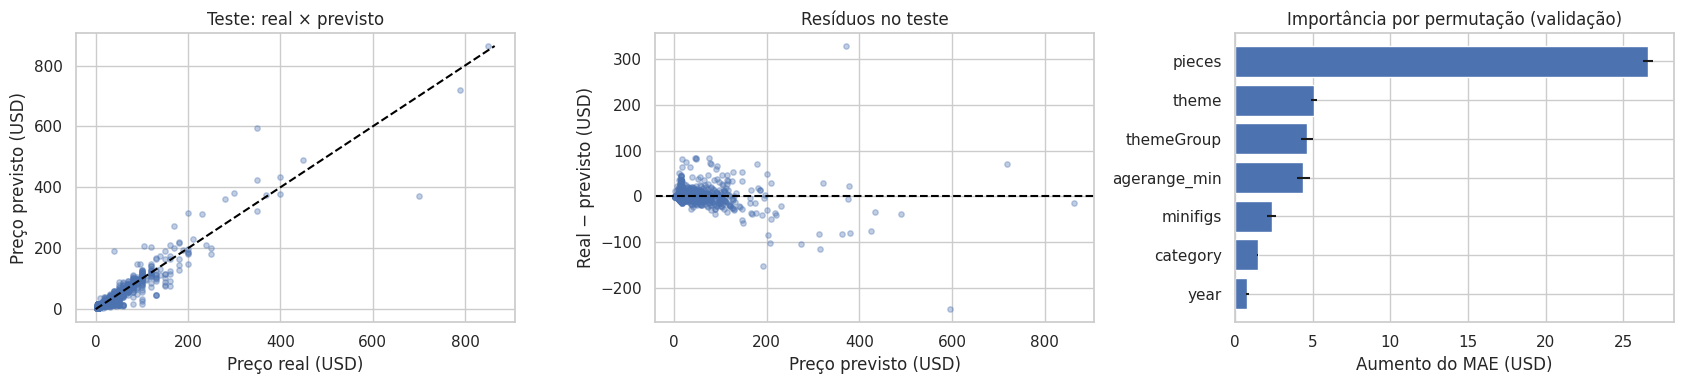

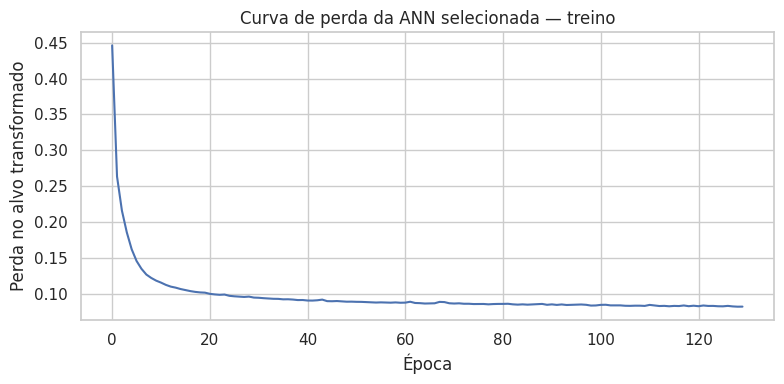

In [9]:
pred_test = prever(melhor, X_test)
resultado_teste = pd.DataFrame([
    {'modelo': melhor_nome, **metricas(y_test, pred_test)},
    {'modelo': 'Baseline: mediana', **metricas(y_test, baseline.predict(X_test))}
]).set_index('modelo')
display(resultado_teste.round(3))
print('Predições brutas não positivas no teste:', int((melhor.predict(X_test) <= 0).sum()))
with threadpool_limits(limits=2):
    imp = permutation_importance(melhor, X_val, y_val, n_repeats=5,
                                 random_state=SEED, scoring='neg_mean_absolute_error', n_jobs=1)
importancias = pd.DataFrame({'coluna': atributos, 'aumento_MAE_USD': imp.importances_mean,
                            'desvio': imp.importances_std}).sort_values('aumento_MAE_USD', ascending=False)
display(importancias.round(3))
fig, axs = plt.subplots(1, 3, figsize=(17, 4))
axs[0].scatter(y_test, pred_test, alpha=0.35, s=15)
lim = max(float(y_test.max()), float(pred_test.max()))
axs[0].plot([0, lim], [0, lim], '--', color='black')
axs[0].set(title='Teste: real × previsto', xlabel='Preço real (USD)', ylabel='Preço previsto (USD)')
axs[1].scatter(pred_test, y_test.to_numpy() - pred_test, alpha=0.35, s=15)
axs[1].axhline(0, color='black', linestyle='--')
axs[1].set(title='Resíduos no teste', xlabel='Preço previsto (USD)', ylabel='Real − previsto (USD)')
ordenada = importancias.sort_values('aumento_MAE_USD')
axs[2].barh(ordenada['coluna'], ordenada['aumento_MAE_USD'], xerr=ordenada['desvio'])
axs[2].set(title='Importância por permutação (validação)', xlabel='Aumento do MAE (USD)')
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 4))
plt.plot(melhor.named_steps['regressor'].regressor_.loss_curve_)
plt.title('Curva de perda da ANN selecionada — treino')
plt.xlabel('Época')
plt.ylabel('Perda no alvo transformado')
plt.tight_layout()
plt.show()

## 9. Completar todos os preços
Após avaliar o modelo, treinamos uma nova ANN com a configuração escolhida sobre **todos os preços conhecidos**, para aproveitar a base disponível na imputação. As métricas acima pertencem ao modelo avaliado, e não a este reajuste final.

Criamos `price`, `price_source` e indicadores de cautela. O marcador de extrapolação verifica categorias inéditas e atributos numéricos fora da faixa conhecida. Esses indicadores são alertas de cobertura, **não intervalos de confiança**.

In [10]:
modelo_final = criar_modelo(melhores_camadas, melhor_alvo)
with threadpool_limits(limits=2):
    modelo_final.fit(X, y)
sem_preco = lego_df['US_retailPrice'].isna()
lego_df['price'] = lego_df['US_retailPrice'].copy()
lego_df.loc[sem_preco, 'price'] = prever(modelo_final, lego_df.loc[sem_preco, atributos]).round(2)
lego_df['price_source'] = np.where(sem_preco, 'estimated_ann', 'observed')
lego_df['missing_feature_count'] = lego_df[atributos].isna().sum(axis=1)
lego_df['prediction_extrapolation'] = False
for col in categoricas:
    categorias_treino = set(X[col].fillna('Desconhecido'))
    desconhecido = ~lego_df[col].fillna('Desconhecido').isin(categorias_treino)
    lego_df.loc[sem_preco & desconhecido, 'prediction_extrapolation'] = True
for col in numericas:
    fora = lego_df[col].lt(X[col].min()) | lego_df[col].gt(X[col].max())
    lego_df.loc[sem_preco & fora, 'prediction_extrapolation'] = True
lego_df['prediction_caution'] = sem_preco & (
    lego_df['prediction_extrapolation'] | lego_df['missing_feature_count'].ge(2))

# Verificações essenciais do requisito: todo conjunto recebe preço e observados ficam intactos.
assert len(lego_df) == len(lego_original.drop_duplicates())
assert lego_df['price'].notna().all()
assert np.isfinite(lego_df['price']).all()
assert lego_df['price'].gt(0).all()
assert np.array_equal(lego_df.loc[~sem_preco, 'price'].to_numpy(),
                      lego_df.loc[~sem_preco, 'US_retailPrice'].to_numpy())
assert set(X_train.index).isdisjoint(X_val.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_val.index).isdisjoint(X_test.index)
print('Verificações aprovadas: todos os preços preenchidos; preços observados preservados; partições separadas.')
display(lego_df.loc[sem_preco, ['set_id', 'name', *atributos, 'US_retailPrice', 'price',
                             'price_source', 'prediction_caution']].head(15))
display(lego_df.groupby('price_source')['price'].agg(['count', 'mean', 'median', 'min', 'max']).round(2))
print('Estimativas com alerta de cautela:', int(lego_df['prediction_caution'].sum()))

Verificações aprovadas: todos os preços preenchidos; preços observados preservados; partições separadas.


,set_id,name,year,pieces,minifigs,agerange_min,theme,themeGroup,category,US_retailPrice,price,price_source,prediction_caution
0,1-8,Small house set,1970.0,67.0,NaN,NaN,Minitalia,Vintage,Normal,NaN,1.49,estimated_ann,True
1,2-8,Medium house set,1970.0,109.0,NaN,NaN,Minitalia,Vintage,Normal,NaN,1.88,estimated_ann,True
2,3-6,Medium house set,1970.0,158.0,NaN,NaN,Minitalia,Vintage,Normal,NaN,2.40,estimated_ann,True
3,4-4,Large house set,1970.0,233.0,NaN,NaN,Minitalia,Vintage,Normal,NaN,3.28,estimated_ann,True
4,4-6,Mini House and Vehicles,1970.0,NaN,NaN,NaN,Samsonite,Vintage,Normal,NaN,2.43,estimated_ann,True
5,078-1,Roadway Base Plate 50X50,1970.0,1.0,NaN,NaN,Samsonite,Vintage,Normal,NaN,0.99,estimated_ann,True
6,104-1,4.5V Replacement Motor,1970.0,1.0,NaN,NaN,Trains,Modern day,Normal,NaN,9.14,estimated_ann,True
7,126-1,Steam Locomotive (Push),1970.0,60.0,NaN,NaN,Trains,Modern day,Normal,NaN,10.55,estimated_ann,True
8,157-3,4 Car Auto Transport,1970.0,65.0,NaN,NaN,Samsonite,Vintage,Normal,NaN,1.48,estimated_ann,True
9,242-4,Big Model Book,1970.0,NaN,NaN,NaN,Books,Miscellaneous,Book,NaN,5.20,estimated_ann,True


,count,mean,median,min,max
price_source,,,,,
estimated_ann,11475,15.74,8.34,0.25,911.37
observed,6982,37.53,19.99,1.49,849.99


Estimativas com alerta de cautela: 7654


## 10. Visualização dos preços completados e exportação

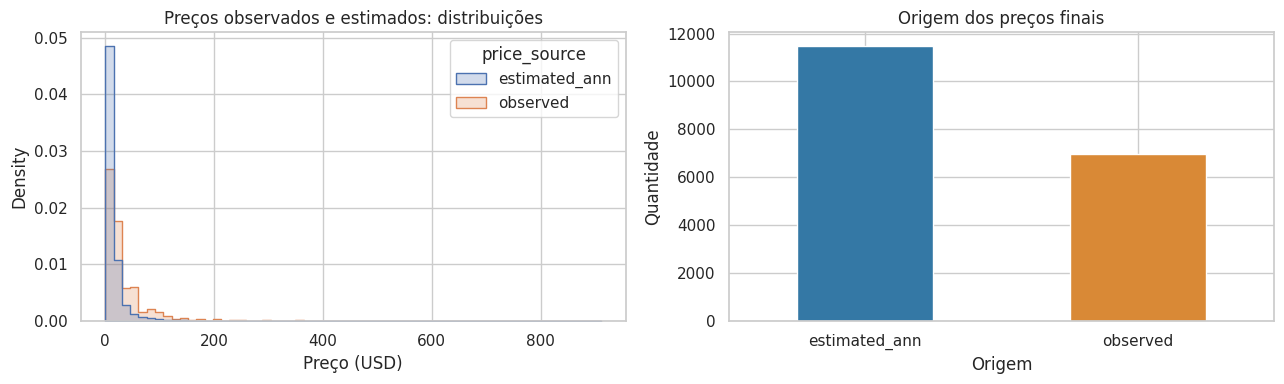

Arquivos exportados para: /workspace/scratch/a1959f231b17/lego_lab/resultados_lego
importancia_colunas.csv
lego_precos_estimados.csv
lego_sets_com_precos.csv
metadados_modelo.json
metricas_teste.csv
metricas_validacao.csv
modelo_ann_lego.joblib


In [11]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=lego_df, x='price', hue='price_source', bins=60,
             stat='density', common_norm=False, element='step', ax=axs[0])
axs[0].set(title='Preços observados e estimados: distribuições', xlabel='Preço (USD)')
resumo_origem = lego_df['price_source'].value_counts()
resumo_origem.plot.bar(ax=axs[1], color=['#3478a5', '#d98936'])
axs[1].set(title='Origem dos preços finais', xlabel='Origem', ylabel='Quantidade')
axs[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

lego_df.to_csv(SAIDA / 'lego_sets_com_precos.csv', index=False, encoding='utf-8-sig')
lego_df.loc[sem_preco].to_csv(SAIDA / 'lego_precos_estimados.csv', index=False, encoding='utf-8-sig')
comparacao.to_csv(SAIDA / 'metricas_validacao.csv', encoding='utf-8-sig')
resultado_teste.to_csv(SAIDA / 'metricas_teste.csv', encoding='utf-8-sig')
importancias.to_csv(SAIDA / 'importancia_colunas.csv', index=False, encoding='utf-8-sig')
# Carregue arquivos joblib apenas de fontes confiáveis e em ambiente compatível.
joblib.dump(modelo_final, SAIDA / 'modelo_ann_lego.joblib')
metadados = {'seed': SEED, 'atributos': atributos, 'arquitetura': list(melhores_camadas),
             'transformacao_alvo': melhor_alvo, 'selecao': 'menor MAE na validacao',
             'linhas': len(lego_df), 'precos_estimados': int(sem_preco.sum()),
             'precos_observados': int((~sem_preco).sum()),
             'metricas_teste': metricas(y_test, pred_test),
             'sklearn_version': sklearn.__version__, 'moeda': 'USD',
             'alvo': 'preco de varejo dos EUA no lancamento', 'url_dados': URL}
(SAIDA / 'metadados_modelo.json').write_text(json.dumps(metadados, indent=2, ensure_ascii=False), encoding='utf-8')
print('Arquivos exportados para:', SAIDA.resolve())
for arquivo in sorted(SAIDA.iterdir()):
    print(arquivo.name)

## 11. Conclusão e limitações
A célula seguinte resume os resultados efetivamente calculados. Os preços ausentes não são aleatórios: categorias, épocas e temas têm coberturas diferentes. Por isso, o desempenho em conjuntos com preço conhecido **não garante** o mesmo erro nos conjuntos sem preço.

Estimativas com poucas características disponíveis, temas inéditos ou épocas pouco representadas exigem cautela. Não aplicamos correção monetária. O modelo estima o preço de lançamento em USD, sem garantir que o produto tenha sido comercializado nos Estados Unidos. Itens sem preço porque não eram vendidos individualmente ainda recebem uma estimativa matemática para cumprir o LAB; ela não demonstra um preço comercial real.

In [12]:
m = metricas(y_test, pred_test)
b = metricas(y_test, baseline.predict(X_test))
print(f"Base final: {len(lego_df):,} conjuntos; {(~sem_preco).sum():,} preços observados e {sem_preco.sum():,} estimados.")
print(f"ANN escolhida: {melhor_nome}.")
print(f"Teste: MAE = US$ {m['MAE_USD']:.2f}; RMSE = US$ {m['RMSE_USD']:.2f}; R² = {m['R2']:.3f}.")
print(f"Baseline mediana: MAE = US$ {b['MAE_USD']:.2f}.")
print('Colunas mais relevantes na validação:', ', '.join(importancias.head(3)['coluna']))
print('A ANN superou a mediana no MAE de teste.' if m['MAE_USD'] < b['MAE_USD'] else
      'A ANN não superou a mediana no MAE de teste; essa limitação deve ser relatada.')
print('A coluna price não contém valores ausentes e mantém todos os preços observados.')

Base final: 18,457 conjuntos; 6,982 preços observados e 11,475 estimados.
ANN escolhida: ANN (64, 32) — log.
Teste: MAE = US$ 8.64; RMSE = US$ 19.09; R² = 0.886.
Baseline mediana: MAE = US$ 25.81.
Colunas mais relevantes na validação: pieces, theme, themeGroup
A ANN superou a mediana no MAE de teste.
A coluna price não contém valores ausentes e mantém todos os preços observados.
